In [12]:
import numpy as np 
import matplotlib.pyplot as plt 

In [13]:
plt.rcParams["figure.dpi"] = 140

In [14]:
class Lattice:
    def __init__(self,length=10,vacancy=1,seed=42):
        
        np.random.seed(seed)
        
        self.length = length
        self.vacancy = vacancy 
        self.vacancyPos = []
        
        self.grid = np.ones((length,length))
        
        #Chose a random position for vacancies
        for _ in range(vacancy):
            idx = np.random.choice(length*length,replace=False)
            x = idx // length
            y = idx % length
            
            self.grid[x,y] = 0 
            self.vacancyPos.append((x,y))
    
    def PrintLattice(self):
        atoms = np.argwhere(self.grid==1)
        vacancy = np.argwhere(self.grid==0)
        
        if len(atoms) > 0:
            plt.scatter(atoms[:,0],atoms[:,1],c="blue")
        if len(vacancy) > 0:
            plt.scatter(vacancy[:,0],vacancy[:,1],c="red")
        plt.show()
    
    def RejectionKMC(self,Ea=2,iterations=1000,T=800,dt=0.001):
        "Note that the msd is calculated for 1 vacancy."
        t = 0.
        kb = 8.61e-5
        
        diffusion = []
        time = []
        msdList = []
        
        nu = 1e13
        jumpProb = min(1,nu*dt*np.exp(-Ea/(kb*T)))
        
        directions = [(1,0),(-1,0),(0,1),(0,-1)]
        
        x0,y0 = self.vacancyPos[-1][0],self.vacancyPos[-1][1]
        unwrapX,unwrapY = x0,y0
        
        for _ in range(iterations):
            for i,(x,y) in enumerate(self.vacancyPos):
                idx = np.random.choice(len(directions))
                
                dx,dy = directions[idx][0],directions[idx][1]
                
                newX = (x+dx) % self.length
                newY = (y+dy) % self.length
                
                if np.random.rand() < jumpProb:
                    self.grid[x,y] = 1 
                    self.grid[newX,newY] = 0
                    
                    self.vacancyPos[i] = [newX,newY]
                    
                    unwrapX += dx
                    unwrapY += dy
                    
            totalDx,totalDy = (unwrapX-x0),(unwrapY-y0)
            t += dt
            msd = totalDx**2 + totalDy**2
            D = msd/(4*t)
            diffusion.append(D)
            time.append(t)
            msdList.append(msd)
            
        plt.title("MSD vs Time (Rejection KMC)")
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.grid()
        plt.plot(time,msdList)
        plt.show()
        
        plt.title('Diffusion vs Time (Rejection KMC)')
        plt.xlabel("Time")
        plt.ylabel("Diffusion")
        plt.grid()
        plt.plot(time,diffusion,c="red")
        plt.show() 
        
        self.PrintLattice()       
        return D 

    def RejectionFreeKMC(self,rates,Ea=2,iterations=1000,T=800):
        R = np.sum(rates,axis=0)
        P = rates / R 
        t = 0.
        time = []
        msdList = []
        diffusion = []
        x0,y0 = self.vacancyPos[-1][0],self.vacancyPos[-1][1]
        unwrapX,unwrapY=x0,y0
        
        
        directions = [(1,0),(-1,0),(0,1),(0,-1)]
        cumSum = np.cumsum(P)
        for _ in range(iterations):
            for i ,(x,y) in enumerate(self.vacancyPos):
                u = np.random.rand()
                idx = np.searchsorted(cumSum, u) # Gives the type of Event
                dx,dy = directions[idx][0],directions[idx][1]
                newX = (x+dx) % self.length
                newY = (y+dy) % self.length
                
                self.grid[x,y] = 1 
                self.grid[newX,newY] = 0
                
                self.vacancyPos[i] = [newX,newY]
                unwrapX += dx
                unwrapY += dy 
                
                u2 = np.random.rand()
                dt = -(np.log(u2)) / R 
            
            t += dt   
            time.append(t)
            totalDx,totalDy = np.power((unwrapX-x0),2),np.power((unwrapY-y0),2)
            msd = totalDx + totalDy 
            msdList.append(msd)
            
            D = msd / (4*t)
            diffusion.append(D)
            
        plt.title("MSD vs Time (Rejection Free)")
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.plot(time,msdList)
        plt.show()
        
        plt.title("Diffusion vs Time (Rejection Free)")
        plt.xlabel("Time")
        plt.ylabel("Diffusion")
        plt.plot(time,diffusion)
        plt.show()
        
        return D 

In [15]:
myLattice = Lattice(vacancy=1)

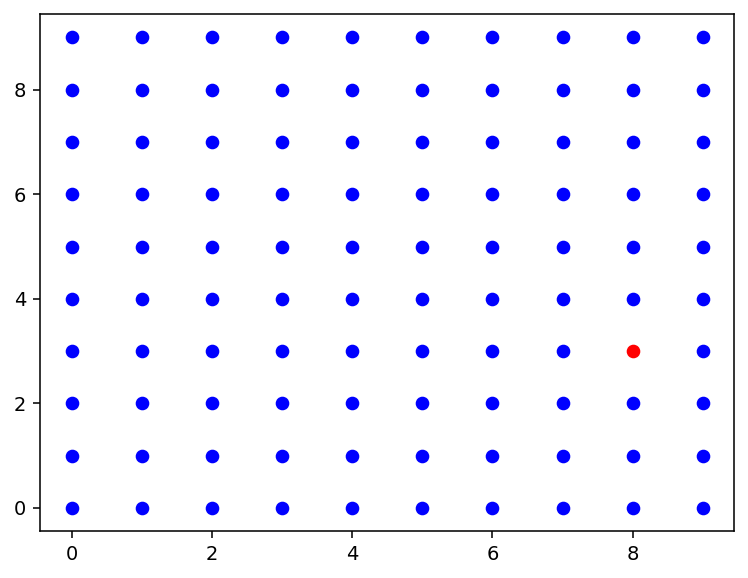

In [16]:
myLattice.PrintLattice()

In [17]:
np.log(np.e)

np.float64(1.0)

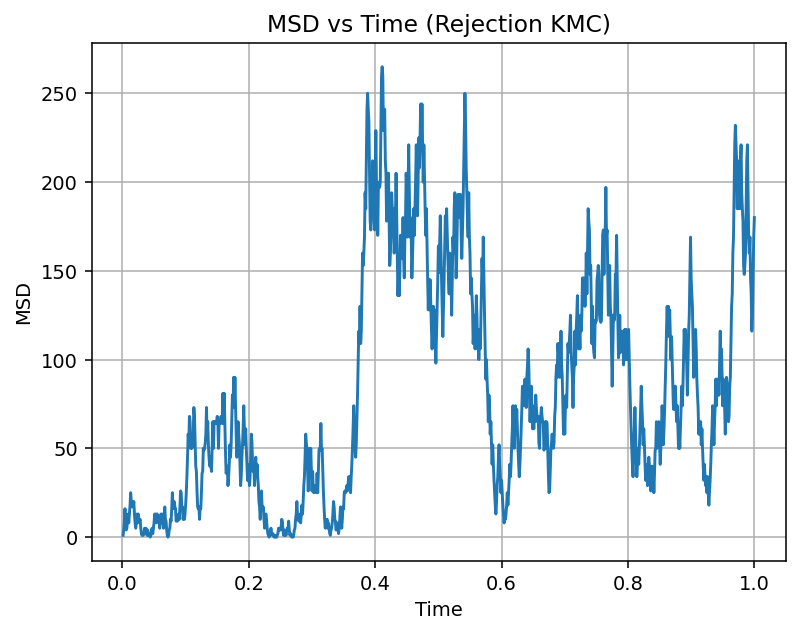

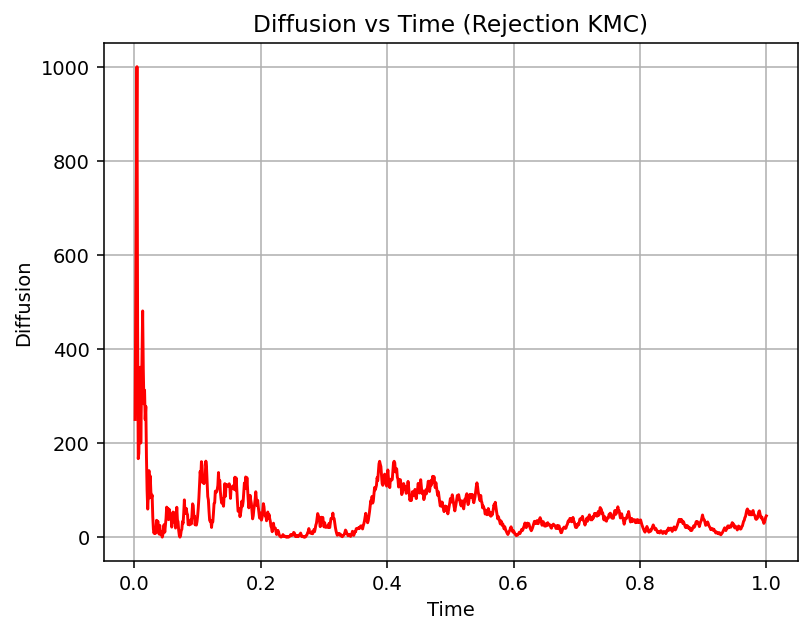

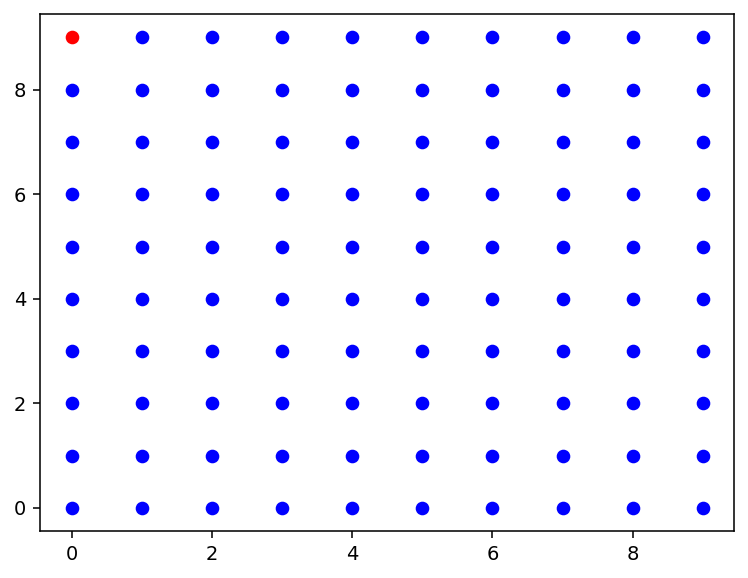

44.99999999999997

In [18]:
myLattice.RejectionKMC(iterations=1000,Ea=2,T=8000)

In [19]:
myLattice.vacancyPos

[[0, 9]]

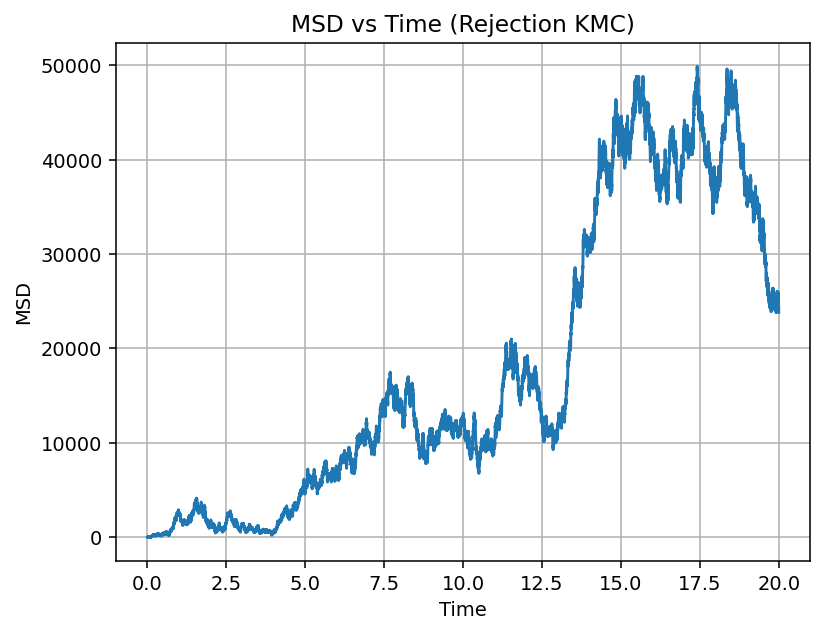

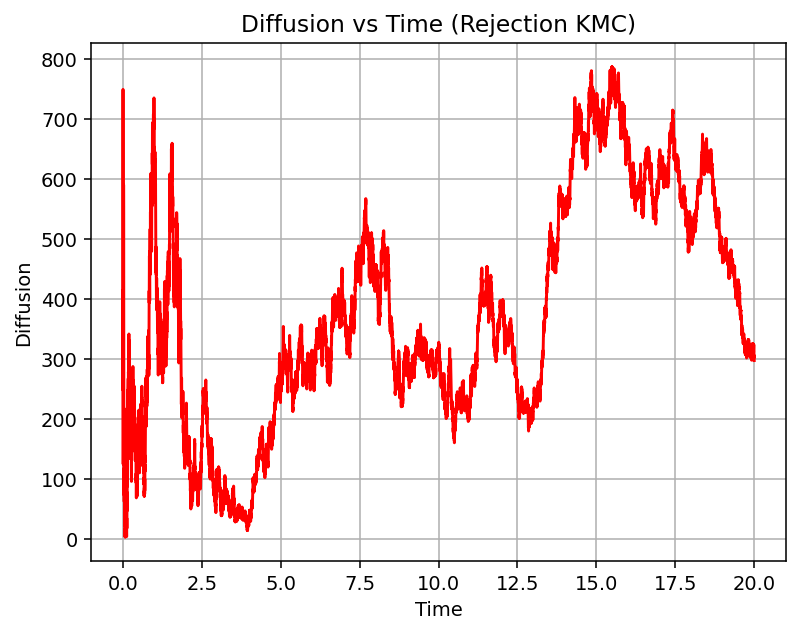

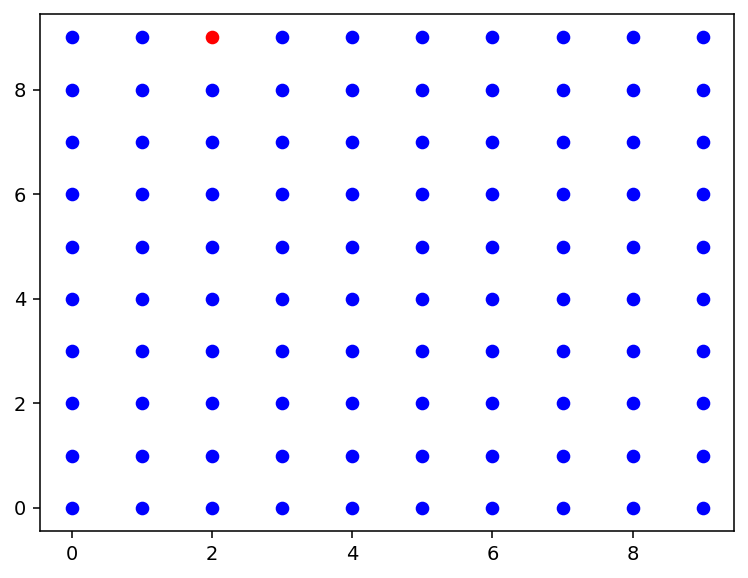

297.79999999997824

In [20]:
myLattice.RejectionKMC(Ea=0.2,T=10000,iterations=20000)


In [21]:
rates = np.array([1,2,3,1]).T
rates.reshape(4,1)

array([[1],
       [2],
       [3],
       [1]])

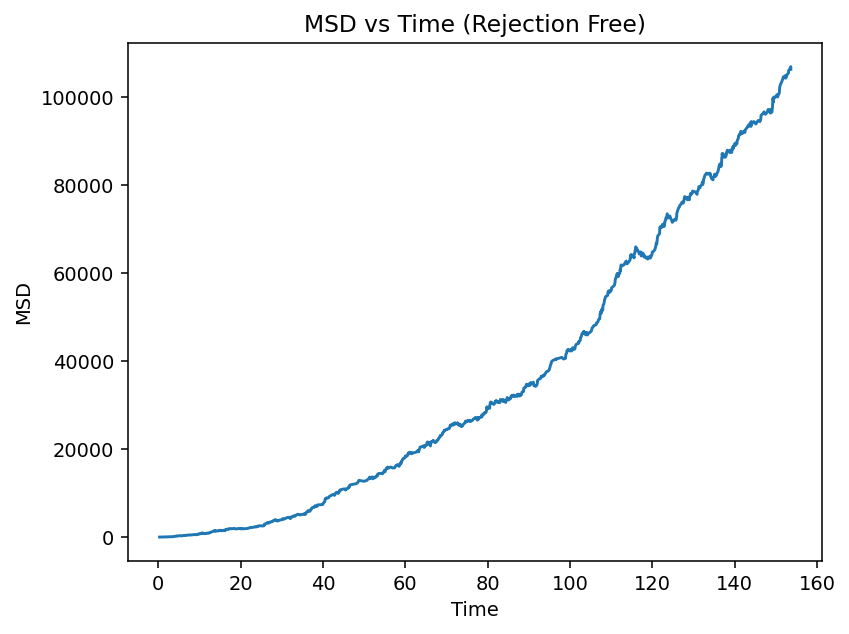

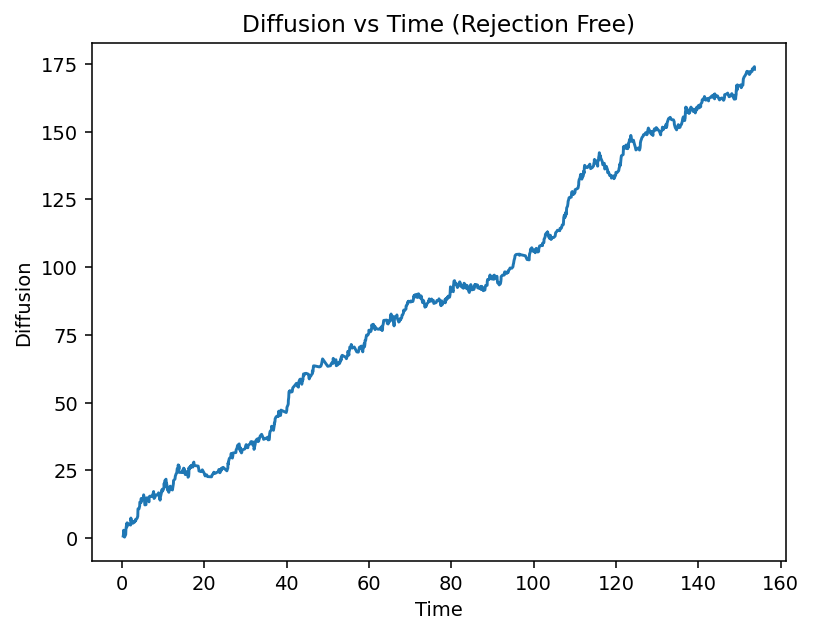

np.float64(172.94633393656545)

In [22]:
myLattice.RejectionFreeKMC(rates=rates,Ea=0.2,T=1000,iterations=1000)
